In [1]:
%load_ext autoreload
%autoreload 2

## S0: Temporal Persistence
Oracle δ vs LS δ, NMSE from reuse.

In [2]:
import sys; sys.path.insert(0, "../..")  # project root
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from src.experiments.pipeline import load_all_ues, run_s0, run_s1, run_s2, run_s3, run_s4, run_s5, run_s7, SPEED_LABELS
plt.style.use("seaborn-v0_8-whitegrid")

PRESET = "munich_elaa_m_1k_15g"
MAX_SNAPSHOTS = 1000
UE_PER_SPEED = 2


In [3]:

# Phase 1: Load UEs (slow, ~3min). Stays in RAM for all experiments.
ue_data = load_all_ues(PRESET, max_snapshots=MAX_SNAPSHOTS, ue_per_speed=UE_PER_SPEED)

Loaded munich_elaa_m_1k_15g: 1000 snaps, 9 UEs, dt=0.00025s


CIR→CFR (8 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (8 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (8 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (8 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

...

CIR→CFR (8 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (8 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (8 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (8 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

Loaded 6 UEs into RAM (50.3 GB)


S0: UEs:   0%|          | 0/6 [00:00<?, ?ue/s]

  S0 UE0 δ:   0%|          | 0/999 [00:00<?, ?snap/s]

  S0 UE1 δ:   0%|          | 0/999 [00:00<?, ?snap/s]

  S0 UE3 δ:   0%|          | 0/999 [00:00<?, ?snap/s]

  S0 UE4 δ:   0%|          | 0/999 [00:00<?, ?snap/s]

  S0 UE6 δ:   0%|          | 0/999 [00:00<?, ?snap/s]

  S0 UE8 δ:   0%|          | 0/999 [00:00<?, ?snap/s]

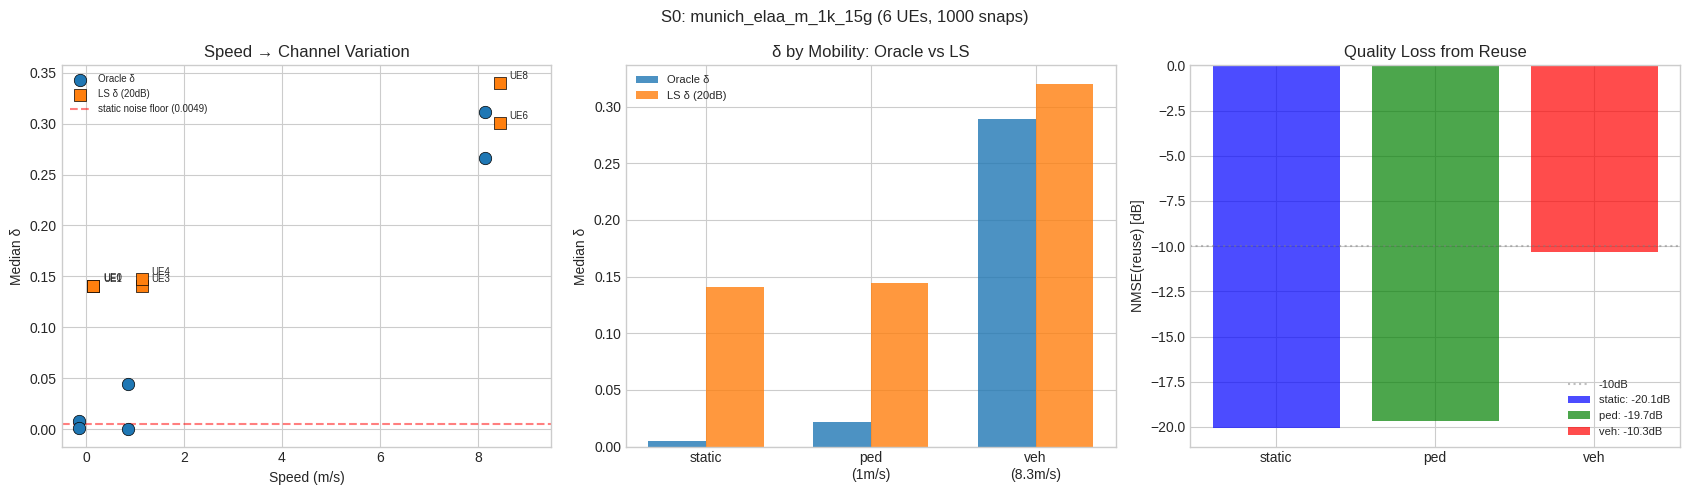

GO/NO-GO: GO ✓ (median δ = 0.0262)


In [4]:
s0 = run_s0(ue_data)

per_ue = s0["per_ue"]
summary = s0["summary"]
speeds = np.array([u["speed"] for u in per_ue])
deltas_oracle = np.array([u["median_delta"] for u in per_ue])
deltas_ls = np.array([u.get("median_delta_ls", u["median_delta"]) for u in per_ue])
nmses = np.array([u["nmse_reuse_db"] for u in per_ue])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1a: Speed vs δ
ax = axes[0]
for i, u in enumerate(per_ue):
    spd, d_o, d_l = u["speed"], u["median_delta"], u.get("median_delta_ls", u["median_delta"])
    ax.scatter(spd - 0.15, d_o, c="tab:blue", s=80, edgecolors="k", linewidths=0.5, marker="o",
               label="Oracle δ" if i == 0 else "", zorder=5)
    ax.scatter(spd + 0.15, d_l, c="tab:orange", s=80, edgecolors="k", linewidths=0.5, marker="s",
               label="LS δ (20dB)" if i == 0 else "", zorder=5)
    ax.annotate(f"UE{u['uid']}", (spd + 0.2, max(d_o, d_l)), textcoords="offset points", xytext=(5, 3), fontsize=7)
ax.axhline(summary["static_median_delta"], color="red", ls="--", alpha=0.5,
           label=f"static noise floor ({summary['static_median_delta']:.4f})")
ax.set_xlabel("Speed (m/s)"); ax.set_ylabel("Median δ"); ax.set_xlim(-0.5, 9.5)
ax.set_title("Speed → Channel Variation"); ax.legend(fontsize=7, loc="upper left")

# 1b: Grouped bar
ax = axes[1]
cats = {"static": 0.0, "ped\n(1m/s)": 1.0, "veh\n(8.3m/s)": 8.3}
x_pos = np.arange(len(cats)); w = 0.35
for j, (arr, lbl, c) in enumerate([(deltas_oracle, "Oracle δ", "tab:blue"), (deltas_ls, "LS δ (20dB)", "tab:orange")]):
    vals = [np.median(arr[np.abs(speeds - s) < 0.1]) if (np.abs(speeds - s) < 0.1).any() else 0 for _, s in cats.items()]
    ax.bar(x_pos + (j - 0.5) * w, vals, w, color=c, alpha=0.8, label=lbl)
ax.set_xticks(x_pos); ax.set_xticklabels(cats.keys()); ax.set_ylabel("Median δ")
ax.set_title("δ by Mobility: Oracle vs LS"); ax.legend(fontsize=8)

# 1c: NMSE
ax = axes[2]
for i, (lbl, s) in enumerate({"static": 0.0, "ped": 1.0, "veh": 8.3}.items()):
    mask = np.abs(speeds - s) < 0.1; v = nmses[mask]; v = v[~np.isnan(v)]
    if len(v) > 0: ax.bar(i, np.median(v), color=["blue","green","red"][i], alpha=0.7, label=f"{lbl}: {np.median(v):.1f}dB")
ax.axhline(-10, color="gray", ls=":", alpha=0.5, label="-10dB")
ax.set_xticks(range(3)); ax.set_xticklabels(["static","ped","veh"]); ax.set_ylabel("NMSE(reuse) [dB]")
ax.set_title("Quality Loss from Reuse"); ax.legend(fontsize=8)

fig.suptitle(f"S0: {PRESET} ({summary['n_ues']} UEs, {MAX_SNAPSHOTS} snaps)", fontsize=12)
plt.tight_layout(); plt.show()
print(f"GO/NO-GO: {'GO ✓' if summary['median_delta'] <= 0.5 else 'NO-GO ✗'} (median δ = {summary['median_delta']:.4f})")

## S1: Does Scheduling Work? (Single-τ)
Core question: at τ=0.2, how does adaptive scheduling compare to always-full-CE and always-skip?

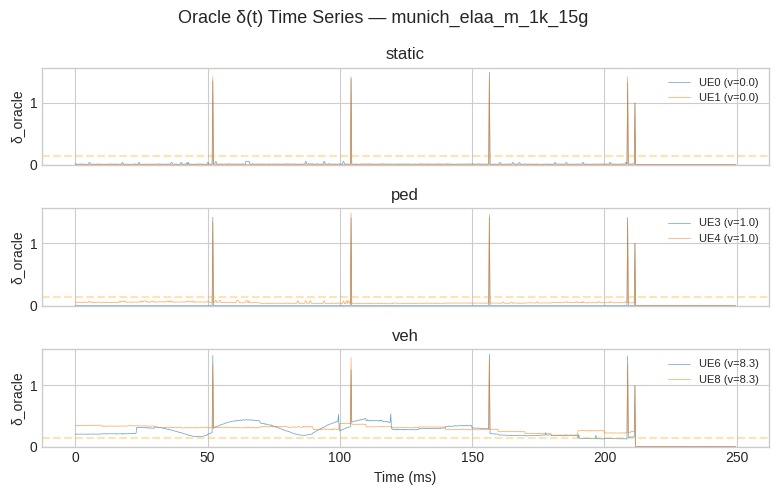

In [10]:
# δ_oracle time series per UE
import torch

fig, axes = plt.subplots(3, 1, figsize=(8, 5), sharex=True)
speed_groups = {"static": [], "ped": [], "veh": []}
for u in ue_data["ue_list"]:
    lbl = "static" if u["speed"] < 0.1 else ("ped" if u["speed"] < 5 else "veh")
    speed_groups[lbl].append(u)

dt_ms = 0.25  # dt in ms
colors_ue = plt.cm.tab10(np.linspace(0, 1, 10))

for ax, (spd_label, ues) in zip(axes, speed_groups.items()):
    for i, u in enumerate(ues):
        h = u["h_real"]
        # Oracle δ: vectorized
        diff = h[1:] - h[:-1]
        ref = h[:-1].flatten(1).norm(dim=1).clamp(min=1e-12)
        delta_oracle = (diff.flatten(1).norm(dim=1) / ref).numpy()
        t_ms = np.arange(len(delta_oracle)) * dt_ms
        ax.plot(t_ms, delta_oracle, color=colors_ue[i], alpha=0.7, lw=0.5,
                label=f"UE{u['uid']} (v={u['speed']:.1f})")
    
    ax.set_ylabel("δ_oracle")
    ax.set_title(f"{spd_label}")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_ylim(bottom=0)
    # Noise floor reference
    ax.axhline(0.14, color="orange", ls="--", alpha=0.3, label="LS noise floor @20dB")

axes[-1].set_xlabel("Time (ms)")
fig.suptitle(f"Oracle δ(t) Time Series — {ue_data['preset']}", fontsize=13)
plt.tight_layout(); plt.show()

### Deep Dive: δ characteristics
1. Spike analysis: how often, how large?
2. Baseline (non-spike) δ by speed
3. Cumulative drift vs time
4. LS δ vs Oracle δ overlay

In [ ]:
# ═══ Analysis 1: Spike detection + baseline separation ═══
spike_threshold = 0.3  # δ > 0.3 = spike (path birth/death event)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
dt_ms = 0.25

for col, (spd_label, ues) in enumerate(speed_groups.items()):
    all_baselines, all_spikes = [], []
    
    for u in ues:
        h = u["h_real"]
        diff = h[1:] - h[:-1]
        ref = h[:-1].flatten(1).norm(dim=1).clamp(min=1e-12)
        delta = (diff.flatten(1).norm(dim=1) / ref).numpy()
        
        is_spike = delta > spike_threshold
        baselines = delta[~is_spike]
        spikes = delta[is_spike]
        all_baselines.extend(baselines.tolist())
        all_spikes.extend(spikes.tolist())
    
    all_baselines = np.array(all_baselines)
    all_spikes = np.array(all_spikes)
    T_total = sum(u["h_real"].shape[0] - 1 for u in ues)
    
    # Top: histogram of baseline δ (no spikes)
    ax = axes[0, col]
    if len(all_baselines) > 0:
        ax.hist(all_baselines, bins=50, color="steelblue", alpha=0.7, density=True)
        ax.axvline(np.median(all_baselines), color="red", ls="--", label=f"median={np.median(all_baselines):.4f}")
        ax.axvline(0.14, color="orange", ls=":", label="LS noise floor")
    ax.set_xlabel("δ_oracle (baseline only)")
    ax.set_title(f"{spd_label}: baseline δ distribution")
    ax.legend(fontsize=7)
    
    # Bottom: spike statistics
    ax = axes[1, col]
    spike_rate = len(all_spikes) / max(T_total, 1) * 100
    ax.bar(["Spike\nRate", "Spike\nMedian", "Spike\nMax", "Baseline\nMedian"], 
           [spike_rate, np.median(all_spikes) if len(all_spikes) > 0 else 0,
            np.max(all_spikes) if len(all_spikes) > 0 else 0,
            np.median(all_baselines) if len(all_baselines) > 0 else 0],
           color=["red", "orange", "darkred", "steelblue"], alpha=0.7)
    ax.set_title(f"{spd_label}: spike stats")
    ax.set_ylabel("Value (δ or %)")
    # Annotate
    for i, v in enumerate([spike_rate, 
                           np.median(all_spikes) if len(all_spikes) > 0 else 0,
                           np.max(all_spikes) if len(all_spikes) > 0 else 0,
                           np.median(all_baselines) if len(all_baselines) > 0 else 0]):
        ax.text(i, v + 0.02, f"{v:.3f}" if v < 10 else f"{v:.1f}%", ha="center", fontsize=8)

fig.suptitle(f"Spike Analysis (threshold={spike_threshold})", fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# ═══ Analysis 2: Cumulative drift — how fast does h_hat go stale? ═══
# ||h(t) - h(t0)||/||h(t0)|| as function of (t - t0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, (spd_label, ues) in enumerate(speed_groups.items()):
    ax = axes[col]
    
    for u in ues:
        h = u["h_real"]  # (T, 2, n_ant, n_sc)
        T = h.shape[0]
        
        # Sample multiple reference points and average
        ref_points = list(range(0, T - 100, max(T // 10, 1)))[:10]
        drift_curves = []
        
        for t0 in ref_points:
            max_lag = min(200, T - t0)  # up to 200 slots (50ms)
            h_ref = h[t0]  # reference channel
            ref_norm = h_ref.flatten().norm().item()
            if ref_norm < 1e-12:
                continue
            
            lags = list(range(0, max_lag, max(max_lag // 50, 1)))
            drift = []
            for lag in lags:
                d = (h[t0 + lag] - h_ref).flatten().norm().item() / ref_norm
                drift.append(d)
            drift_curves.append((lags, drift))
        
        # Average drift curve
        if drift_curves:
            max_len = min(len(dc[1]) for dc in drift_curves)
            avg_lags = np.array(drift_curves[0][0][:max_len]) * dt_ms
            avg_drift = np.mean([dc[1][:max_len] for dc in drift_curves], axis=0)
            ax.plot(avg_lags, avg_drift, label=f"UE{u['uid']} (v={u['speed']:.1f})", lw=1.5)
    
    ax.set_xlabel("Lag (ms)")
    ax.set_ylabel("Cumulative δ from reference")
    ax.set_title(f"{spd_label}: channel staleness over time")
    ax.axhline(0.1, color="gray", ls=":", alpha=0.5, label="10% drift")
    ax.axhline(0.5, color="red", ls=":", alpha=0.5, label="50% drift")
    ax.legend(fontsize=7)
    ax.set_ylim(0, min(1.0, ax.get_ylim()[1]))

fig.suptitle("Cumulative Channel Drift (how fast does estimate go stale?)", fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# ═══ Analysis 3: Oracle δ vs LS δ overlay (per UE) ═══
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

for col, (spd_label, ues) in enumerate(speed_groups.items()):
    for row, u in enumerate(ues[:2]):  # max 2 UEs per speed
        ax = axes[row, col]
        h = u["h_real"]
        h_ls, d_ls, d_oracle, _ = _precompute_deltas(h, 20.0)
        t_ms = np.arange(len(d_oracle)) * dt_ms
        
        ax.plot(t_ms, d_oracle, color="tab:blue", alpha=0.6, lw=0.5, label="Oracle δ")
        ax.plot(t_ms, d_ls, color="tab:orange", alpha=0.6, lw=0.5, label="LS δ (20dB)")
        ax.axhline(0.2, color="green", ls="--", alpha=0.5, label="τ=0.2")
        ax.axhline(0.14, color="red", ls=":", alpha=0.5, label="LS noise floor")
        ax.set_ylabel("δ")
        ax.set_title(f"UE{u['uid']} ({spd_label}, v={u['speed']:.1f})")
        ax.set_ylim(0, 0.6)  # clip spikes
        if row == 0 and col == 0:
            ax.legend(fontsize=6)

axes[-1, 1].set_xlabel("Time (ms)")
fig.suptitle("Oracle δ vs LS δ — τ and noise floor", fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# ═══ Analysis 4: NMSE vs skip interval (how long can you safely skip?) ═══
# For each UE, artificially skip N slots, measure NMSE. 
# This directly answers: "what's the max skip interval before NMSE > -10dB?"

from src.experiments.pipeline import _precompute_deltas, _compute_nmse_from_tiers

skip_intervals = [1, 2, 5, 10, 20, 50, 100, 200, 500]

fig, ax = plt.subplots(figsize=(12, 6))
markers = {"static": "o", "ped": "s", "veh": "^"}

for spd_label, ues in speed_groups.items():
    for u in ues:
        h = u["h_real"]
        T = h.shape[0]
        h_ls, _, _, _ = _precompute_deltas(h, 20.0)
        
        nmses = []
        for interval in skip_intervals:
            if interval >= T:
                nmses.append(float("nan"))
                continue
            # Build tiers: full CE every `interval` slots
            tiers = np.zeros(T, dtype=np.int32)
            tiers[0] = 2
            for t in range(1, T):
                if t % interval == 0:
                    tiers[t] = 2
            nm = _compute_nmse_from_tiers(h, h_ls, tiers)
            nmses.append(float(10 * np.log10(max(np.mean(nm), 1e-30))))
        
        intervals_ms = [i * dt_ms for i in skip_intervals]
        ax.plot(intervals_ms, nmses, marker=markers[spd_label], 
                label=f"UE{u['uid']} ({spd_label}, v={u['speed']:.1f})", lw=1.5, alpha=0.8)

ax.axhline(-10, color="gray", ls=":", label="-10dB threshold")
ax.axhline(-20, color="lightgray", ls=":", label="-20dB (full CE)")
ax.set_xlabel("Skip Interval (ms)")
ax.set_ylabel("NMSE (dB)")
ax.set_xscale("log")
ax.set_title("NMSE vs Skip Interval — Max safe skip duration")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

# Find max safe interval per UE (NMSE ≤ -10dB)
print("\nMax safe skip interval (NMSE ≤ -10dB):")
for spd_label, ues in speed_groups.items():
    for u in ues:
        h = u["h_real"]
        T = h.shape[0]
        h_ls, _, _, _ = _precompute_deltas(h, 20.0)
        safe = 1
        for interval in skip_intervals:
            if interval >= T:
                break
            tiers = np.zeros(T, dtype=np.int32)
            tiers[0] = 2
            for t in range(1, T):
                if t % interval == 0:
                    tiers[t] = 2
            nm = _compute_nmse_from_tiers(h, h_ls, tiers)
            nmse_db = float(10 * np.log10(max(np.mean(nm), 1e-30)))
            if nmse_db <= -10:
                safe = interval
        print(f"  UE{u['uid']} ({spd_label}): {safe} slots = {safe * dt_ms:.2f}ms")

In [ ]:
# ═══ Analysis 5: Coherence time comparison (theoretical vs measured) ═══
c = 3e8
frequency = 15e9  # for elaa_m_1k_15g
wavelength = c / frequency

print(f"Config: f={frequency/1e9:.0f}GHz, λ={wavelength*100:.1f}cm, dt={dt_ms}ms\n")
print(f"{'UE':>5} {'Speed':>8} {'T_c (theory)':>14} {'T_c (slots)':>12} {'Safe skip':>12} {'Ratio':>8}")
print("-" * 65)

for spd_label, ues in speed_groups.items():
    for u in ues:
        v = u["speed"]
        if v < 0.01:
            tc_theory = float("inf")
            tc_slots = float("inf")
        else:
            tc_theory = wavelength / (2 * v)  # seconds
            tc_slots = tc_theory / (dt_ms / 1000)
        
        # Measured safe skip from Analysis 4 (find from data)
        h = u["h_real"]
        T = h.shape[0]
        h_ls, _, _, _ = _precompute_deltas(h, 20.0)
        safe_measured = 1
        for interval in [1, 2, 5, 10, 20, 50, 100, 200, 500]:
            if interval >= T:
                break
            tiers = np.zeros(T, dtype=np.int32)
            tiers[0] = 2
            for t in range(1, T):
                if t % interval == 0:
                    tiers[t] = 2
            nm = _compute_nmse_from_tiers(h, h_ls, tiers)
            if 10 * np.log10(max(np.mean(nm), 1e-30)) <= -10:
                safe_measured = interval
        
        tc_str = f"{tc_theory*1000:.2f}ms" if tc_theory < 1 else "∞"
        slots_str = f"{tc_slots:.0f}" if tc_slots < 10000 else "∞"
        ratio = safe_measured / tc_slots if tc_slots < 10000 and tc_slots > 0 else float("nan")
        
        print(f"UE{u['uid']:>2d}  {v:>6.1f}m/s  {tc_str:>14}  {slots_str:>12}  {safe_measured:>8d} slots  {ratio:>6.2f}x")

print(f"\nRatio = measured_safe / theoretical_T_c")
print(f"  <1: theory is optimistic (skip less than predicted)")
print(f"  >1: theory is conservative (can skip more than predicted)")
print(f"  ≈1: theory matches measurement")

S1: monitor comparison (τ=0.2):   0%|          | 0/6 [00:00<?, ?ue/s]

  UE0 (v=0.0):
    full_ce             : NMSE= -20.7dB  SR=0%
    always_skip         : NMSE= +84.6dB  SR=100%
    ls_monitor          : NMSE= -20.6dB  SR=98%
    oracle_monitor      : NMSE= -20.6dB  SR=98%
    doppler             : NMSE= +67.2dB  SR=98%
    snr_adaptive        : NMSE= -20.6dB  SR=98%
    smoothed_ls_K4      : NMSE= +56.3dB  SR=96%
  UE1 (v=0.0):
    full_ce             : NMSE= -20.7dB  SR=0%
    always_skip         : NMSE= +57.2dB  SR=100%
    ls_monitor          : NMSE= -20.7dB  SR=98%
    oracle_monitor      : NMSE= -20.7dB  SR=98%
    doppler             : NMSE= +40.2dB  SR=98%
    snr_adaptive        : NMSE= -20.7dB  SR=98%
    smoothed_ls_K4      : NMSE= +30.4dB  SR=96%
  UE3 (v=1.0):
    full_ce             : NMSE= -20.7dB  SR=0%
    always_skip         : NMSE= +45.7dB  SR=100%
    ls_monitor          : NMSE= -20.7dB  SR=98%
    oracle_monitor      : NMSE= -20.7dB  SR=98%
    doppler             : NMSE= +39.0dB  SR=98%
    snr_adaptive        : NMSE= -20.7dB  SR

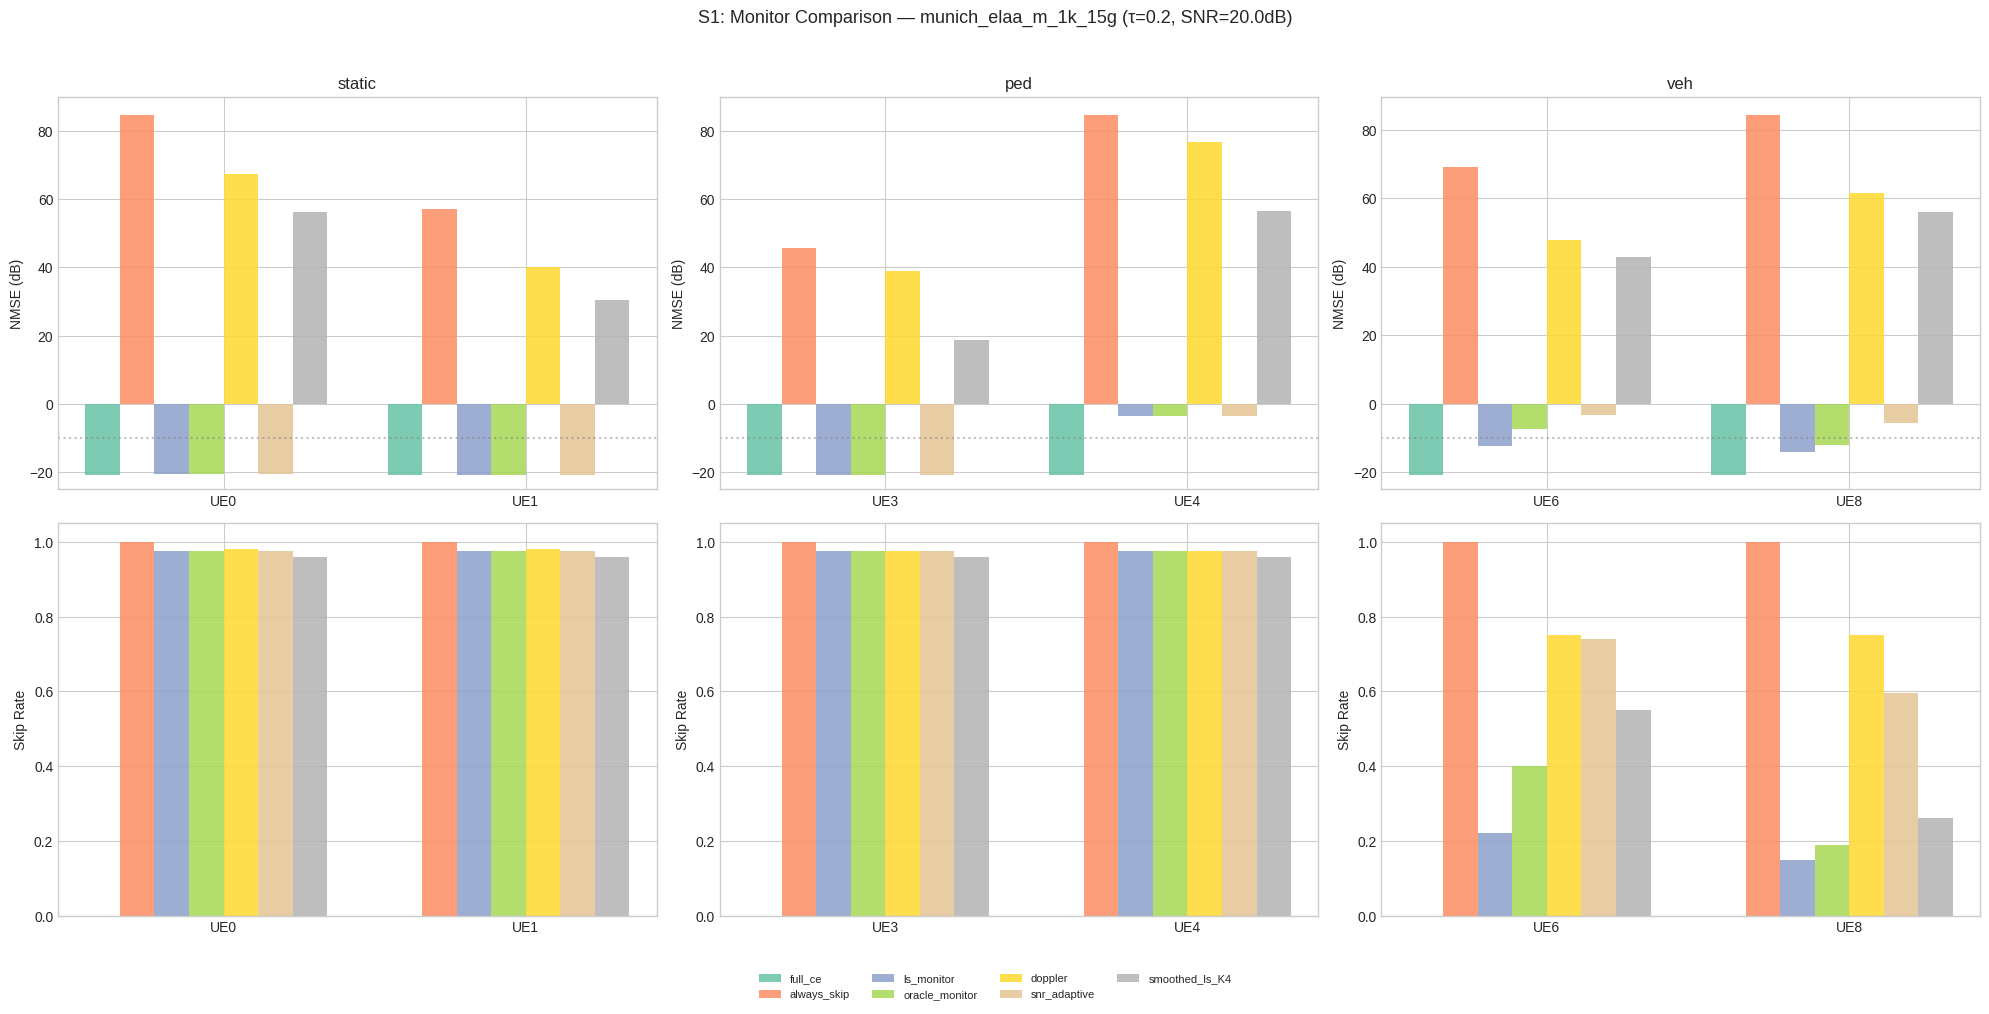


τ_base=0.2, τ_snr_adaptive=0.341

  static:
    Strategy             | UE 0 | UE 1
    --------------------------------------
    full_ce              | -20.7(0%) | -20.7(0%)
    always_skip          | +84.6(100%) | +57.2(100%)
    ls_monitor           | -20.6(98%) | -20.7(98%)
    oracle_monitor       | -20.6(98%) | -20.7(98%)
    doppler              | +67.2(98%) | +40.2(98%)
    snr_adaptive         | -20.6(98%) | -20.7(98%)
    smoothed_ls_K4       | +56.3(96%) | +30.4(96%)

  ped:
    Strategy             | UE 3 | UE 4
    --------------------------------------
    full_ce              | -20.7(0%) | -20.7(0%)
    always_skip          | +45.7(100%) | +84.6(100%)
    ls_monitor           | -20.7(98%) |  -3.4(98%)
    oracle_monitor       | -20.7(98%) |  -3.4(98%)
    doppler              | +39.0(98%) | +76.7(98%)
    snr_adaptive         | -20.7(98%) |  -3.4(98%)
    smoothed_ls_K4       | +18.8(96%) | +56.5(96%)

  veh:
    Strategy             | UE 6 | UE 8
    ------------------

In [5]:
from src.experiments.pipeline import run_s1
s1 = run_s1(ue_data, tau=0.2)

per_ue = s1["per_ue"]
strategy_names = list(per_ue[0]["strategies"].keys())
n_strat = len(strategy_names)
colors = plt.cm.Set2(np.linspace(0, 1, n_strat))

# Group UEs by speed
speed_groups = {"static": [], "ped": [], "veh": []}
for u in per_ue:
    lbl = "static" if u["speed"] < 0.1 else ("ped" if u["speed"] < 5 else "veh")
    speed_groups[lbl].append(u)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for col, (spd_label, ues) in enumerate(speed_groups.items()):
    if not ues:
        continue
    n_ue = len(ues)
    x = np.arange(n_ue)
    w = 0.8 / n_strat

    # Top row: NMSE
    ax = axes[0, col]
    for j, sname in enumerate(strategy_names):
        vals = [u["strategies"][sname]["nmse_db"] for u in ues]
        ax.bar(x + j * w, vals, w, label=sname if col == 0 else "", color=colors[j], alpha=0.85)
    ue_labels = [f"UE{u['uid']}" for u in ues]
    ax.set_xticks(x + w * n_strat / 2); ax.set_xticklabels(ue_labels)
    ax.set_ylabel("NMSE (dB)"); ax.set_title(f"{spd_label}")
    ax.axhline(-10, color="gray", ls=":", alpha=0.5)
    ax.set_ylim(bottom=min(-25, min(u["strategies"][s]["nmse_db"] for u in ues for s in strategy_names if u["strategies"][s]["nmse_db"] > -100) - 2))

    # Bottom row: Skip Rate
    ax = axes[1, col]
    for j, sname in enumerate(strategy_names):
        vals = [u["strategies"][sname]["skip_rate"] for u in ues]
        ax.bar(x + j * w, vals, w, label=sname if col == 0 else "", color=colors[j], alpha=0.85)
    ax.set_xticks(x + w * n_strat / 2); ax.set_xticklabels(ue_labels)
    ax.set_ylabel("Skip Rate"); ax.set_ylim(0, 1.05)

# Shared legend
handles, labels_lg = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_lg, loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(f"S1: Monitor Comparison — {ue_data['preset']} (τ={s1['tau']}, SNR={s1['snr_db']}dB)", fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 0.96]); plt.show()

# Summary table
print(f"\nτ_base={s1['tau']}, τ_snr_adaptive={s1.get('tau_snr_adaptive','?'):.3f}")
for spd_label, ues in speed_groups.items():
    if not ues:
        continue
    print(f"\n  {spd_label}:")
    print(f"    {'Strategy':20s} | " + " | ".join(f"UE{u['uid']:>2d}" for u in ues))
    print(f"    {'-'*22}" + "--------" * len(ues))
    for sname in strategy_names:
        vals = [f"{u['strategies'][sname]['nmse_db']:+5.1f}" for u in ues]
        srs = [f"{u['strategies'][sname]['skip_rate']:.0%}" for u in ues]
        print(f"    {sname:20s} | " + " | ".join(f"{v}({s})" for v, s in zip(vals, srs)))

## S2: Threshold Sweep → Pareto Front
τ sweep: skip rate vs NMSE tradeoff.

S2: UEs:   0%|          | 0/6 [00:00<?, ?ue/s]

    τ sweep:   0%|          | 0/30 [00:00<?, ?τ/s]

  UE0: 30 τ values swept


    τ sweep:   0%|          | 0/30 [00:00<?, ?τ/s]

  UE1: 30 τ values swept


...

  UE4: 30 τ values swept


    τ sweep:   0%|          | 0/30 [00:00<?, ?τ/s]

  UE6: 30 τ values swept


    τ sweep:   0%|          | 0/30 [00:00<?, ?τ/s]

  UE8: 30 τ values swept


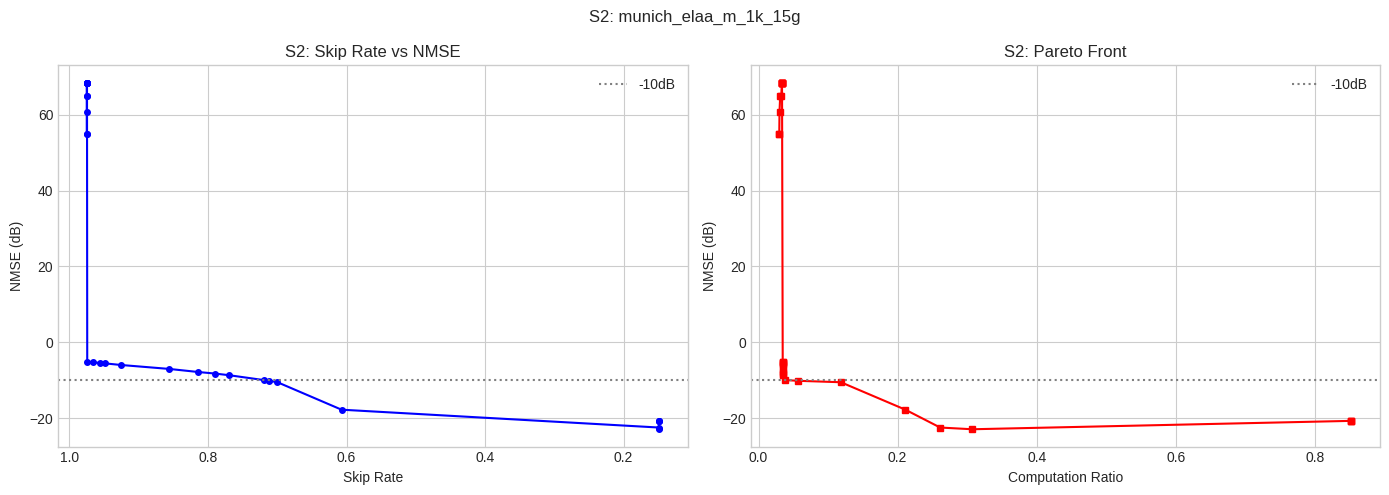

Sweet spot: τ=0.20, SR=71%, CR=0.057, NMSE=-10.2dB


In [6]:
s2 = run_s2(ue_data)

sweep = s2["sweep"]
taus = [s["tau"] for s in sweep]
nmses_s2 = [s["avg_nmse_db"] for s in sweep]
srs = [s["skip_rate"] for s in sweep]
crs = [s["computation_ratio"] for s in sweep]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(srs, nmses_s2, "b-o", ms=4)
ax.set_xlabel("Skip Rate"); ax.set_ylabel("NMSE (dB)"); ax.set_title("S2: Skip Rate vs NMSE")
ax.axhline(-10, color="gray", ls=":", label="-10dB"); ax.legend(); ax.invert_xaxis()

ax = axes[1]
ax.plot(crs, nmses_s2, "r-s", ms=4)
ax.set_xlabel("Computation Ratio"); ax.set_ylabel("NMSE (dB)"); ax.set_title("S2: Pareto Front")
ax.axhline(-10, color="gray", ls=":", label="-10dB"); ax.legend()

fig.suptitle(f"S2: {PRESET}", fontsize=12); plt.tight_layout(); plt.show()

sweet = [s for s in sweep if s["avg_nmse_db"] <= -10]
if sweet:
    best = min(sweet, key=lambda s: s["computation_ratio"])
    print(f"Sweet spot: τ={best['tau']:.2f}, SR={best['skip_rate']:.0%}, CR={best['computation_ratio']:.3f}, NMSE={best['avg_nmse_db']:.1f}dB")

## S4: Delta Update Ablation
Compare T1 modes: pure skip vs EMA vs LS-delta at τ=0.2.

S4: UEs:   0%|          | 0/6 [00:00<?, ?ue/s]

  S4 UE0 modes:   0%|          | 0/7 [00:00<?, ?m/s]

  S4 UE1 modes:   0%|          | 0/7 [00:00<?, ?m/s]

  S4 UE3 modes:   0%|          | 0/7 [00:00<?, ?m/s]

  S4 UE4 modes:   0%|          | 0/7 [00:00<?, ?m/s]

  S4 UE6 modes:   0%|          | 0/7 [00:00<?, ?m/s]

  S4 UE8 modes:   0%|          | 0/7 [00:00<?, ?m/s]

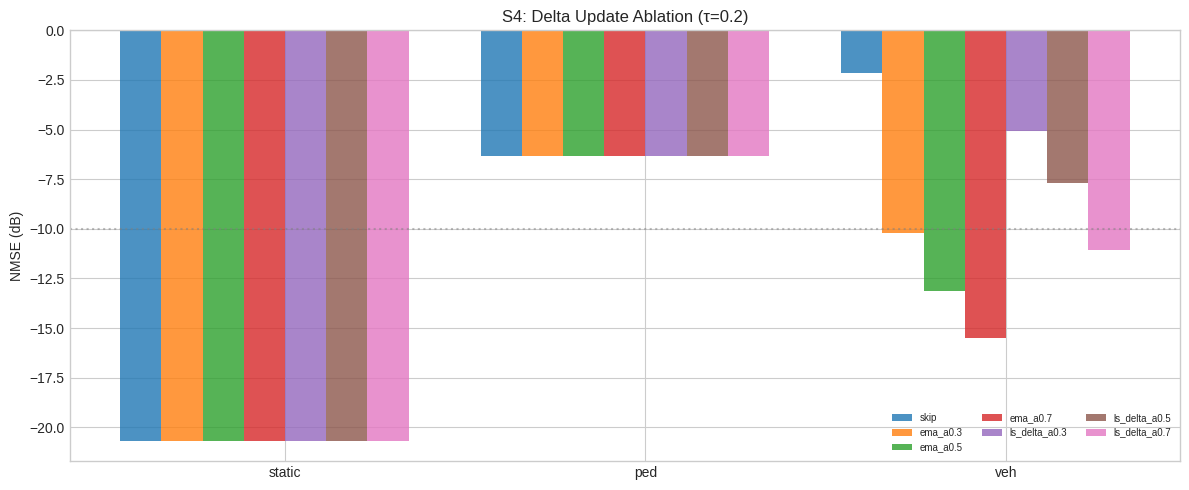

  static: best=skip → -20.7dB
  ped: best=skip → -6.3dB
  veh: best=ema_a0.7 → -15.5dB


In [7]:
s4 = run_s4(ue_data)

modes = list(s4.keys())
speed_cats = ["static", "ped", "veh"]
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(speed_cats)); w = 0.8 / len(modes)
for j, mode in enumerate(modes):
    vals = [s4[mode].get(sc, {}).get("nmse_db", 0) for sc in speed_cats]
    ax.bar(x + j * w, vals, w, label=mode, alpha=0.8)
ax.set_xticks(x + w * len(modes) / 2); ax.set_xticklabels(speed_cats)
ax.set_ylabel("NMSE (dB)"); ax.set_title("S4: Delta Update Ablation (τ=0.2)")
ax.legend(fontsize=7, ncol=3); ax.axhline(-10, color="gray", ls=":", alpha=0.5)
plt.tight_layout(); plt.show()

for sc in speed_cats:
    best = min(modes, key=lambda m: s4[m].get(sc, {}).get("nmse_db", 0))
    print(f"  {sc}: best={best} → {s4[best].get(sc, {}).get('nmse_db', float('nan')):.1f}dB")

## S5: Beamforming Rate Impact
Rate loss from stale channel estimates across SNR × τ.

In [8]:
s5 = run_s5(ue_data)

snr_keys = sorted(s5.keys()); tau_keys = sorted(s5[snr_keys[0]].keys())
rpr_mat = np.array([[s5[sk][tk]["avg_rpr"] for tk in tau_keys] for sk in snr_keys])
rl5_mat = np.array([[s5[sk][tk]["frac_above_5pct"] for tk in tau_keys] for sk in snr_keys])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, cmap, vr, title in [
    (axes[0], rpr_mat, "RdYlGn", (0.8, 1.0), "RPR"),
    (axes[1], rl5_mat, "RdYlGn_r", (0, 0.5), "P(rate_loss > 5%)"),
]:
    im = ax.imshow(mat, aspect="auto", cmap=cmap, vmin=vr[0], vmax=vr[1])
    ax.set_xticks(range(len(tau_keys))); ax.set_xticklabels([t.replace("tau","τ=") for t in tau_keys], fontsize=8)
    ax.set_yticks(range(len(snr_keys))); ax.set_yticklabels([s.replace("snr","")+"dB" for s in snr_keys])
    ax.set_xlabel("τ"); ax.set_ylabel("SNR"); ax.set_title(f"S5: {title}")
    for i in range(len(snr_keys)):
        for j in range(len(tau_keys)):
            fmt = f"{mat[i,j]:.3f}" if "RPR" in title else f"{mat[i,j]:.0%}"
            ax.text(j, i, fmt, ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax)
fig.suptitle(f"S5: {PRESET}", fontsize=12); plt.tight_layout(); plt.show()

print("Sweet spots (RPR>0.95, P(rl>5%)<10%):")
for i, sk in enumerate(snr_keys):
    for j, tk in enumerate(tau_keys):
        if rpr_mat[i,j] > 0.95 and rl5_mat[i,j] < 0.10:
            print(f"  ✓ {sk} {tk}: RPR={rpr_mat[i,j]:.3f}")

S5: UEs:   0%|          | 0/6 [00:00<?, ?ue/s]

  S5 UE0 SNR:   0%|          | 0/4 [00:00<?, ?snr/s]

    τ sweep:   0%|          | 0/4 [00:00<?, ?τ/s]

    τ sweep:   0%|          | 0/4 [00:00<?, ?τ/s]

    τ sweep:   0%|          | 0/4 [00:00<?, ?τ/s]

KeyboardInterrupt: 

## S3: Distance-Dependent Threshold
UEs classified by Rayleigh distance zones.

In [ ]:
s3 = run_s3(ue_data)
r_ray = s3["r_rayleigh"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for u in s3["per_ue"]:
    c = {"NF": "red", "Transition": "orange", "FF": "blue"}.get(u["zone"], "gray")
    s0_match = [x for x in s0["per_ue"] if x["uid"] == u["uid"]]
    d = s0_match[0]["median_delta"] if s0_match else 0
    ax.scatter(u["dist"], d, c=c, s=80, edgecolors="k", linewidths=0.5, zorder=5)
    ax.annotate(f"UE{u['uid']}", (u["dist"], d), textcoords="offset points", xytext=(5, 3), fontsize=7)
ax.axvline(r_ray, color="red", ls="--", alpha=0.5, label=f"R_Ray={r_ray:.1f}m")
ax.axvline(3 * r_ray, color="orange", ls="--", alpha=0.5, label=f"3×R_Ray={3*r_ray:.1f}m")
ax.set_xlabel("Distance (m)"); ax.set_ylabel("Median δ_oracle"); ax.set_title("S3: δ vs Distance"); ax.legend(fontsize=8)

ax = axes[1]
zones = ["NF", "Transition", "FF"]
taus_z = [s3["zones"].get(z, {}).get("optimal_tau", 0) or 0 for z in zones]
counts = [s3["zones"].get(z, {}).get("count", 0) for z in zones]
ax.bar(range(3), taus_z, color=["red", "orange", "blue"], alpha=0.7)
for i, (t, c) in enumerate(zip(taus_z, counts)):
    ax.text(i, t + 0.01, f"τ*={t:.2f}\n(n={c})", ha="center", fontsize=9)
ax.set_xticks(range(3)); ax.set_xticklabels(zones); ax.set_ylabel("Optimal τ*"); ax.set_title("S3: Distance-Dependent τ*")

fig.suptitle(f"S3: {PRESET} (R_Ray={r_ray:.1f}m)", fontsize=12); plt.tight_layout(); plt.show()

## S7: System Overhead & Effective Throughput
Scheduling overhead breakdown + system capacity gain.

In [ ]:
s7 = run_s7(ue_data, s2_result=s2)

oh = s7["overhead"]; eff = s7["effective_throughput"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(["LS\n(Y/X)", "Monitor\n(δ calc)", "Full CE\n(LMMSE)"],
              [oh["t_ls_ms"], oh["t_monitor_ms"], oh["t_full_ce_ms"]],
              color=["lightblue", "orange", "red"], alpha=0.8)
ax.set_ylabel("Time (ms)"); ax.set_yscale("log"); ax.set_title("S7: Component Times")
for b, t in zip(bars, [oh["t_ls_ms"], oh["t_monitor_ms"], oh["t_full_ce_ms"]]):
    ax.text(b.get_x() + b.get_width()/2, t * 1.5, f"{t:.2e}ms", ha="center", fontsize=8)
ax.text(0.95, 0.95, f"Overhead: {oh['overhead_ratio']:.4%}\nMemory: {oh['memory_bytes']/1024:.0f}KB",
        transform=ax.transAxes, va="top", ha="right", fontsize=9, bbox=dict(boxstyle="round", fc="wheat", alpha=0.8))

ax = axes[1]
vals = [eff["per_ue_rate_factor"], eff["capacity_multiplier"], eff["system_throughput_gain"]]
bars = ax.bar(["Per-UE\nRate", "Capacity\nMultiplier", "System\nThroughput"], vals, color=["green","blue","purple"], alpha=0.7)
ax.axhline(1.0, color="gray", ls="--", alpha=0.5)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.1, f"{v:.2f}x", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Multiplier"); ax.set_title("S7: System Impact")

fig.suptitle(f"S7: {PRESET}", fontsize=12); plt.tight_layout(); plt.show()
print(f"Overhead: {oh['overhead_ratio']:.4%} | Capacity: {eff['capacity_multiplier']:.1f}x | Throughput: {eff['system_throughput_gain']:.1f}x")